# Local Group SBI notebook (practical-guide style)

This notebook is a simpler SBI workflow that follows the structure of the `sbi-practical-guide` examples more closely: prepare the data, define `theta` and `x`, train NPE directly with `append_simulations(...).train()`, build the posterior, and sample from it.

It is intentionally lighter than the existing `lg_sbi.py` workflow and keeps the main SBI calls visible in the notebook.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import illustris_python as il
from IPython.display import display

candidate_paths = [
    Path.cwd(),
    Path.cwd() / "scripts",
    Path.cwd().parent / "scripts",
    Path.cwd() / "illustris_python",
    Path.cwd().parent / "illustris_python",
]
for p in candidate_paths:
    if p.exists():
        sys.path.insert(0, str(p))

import lg_analogues as lg
from lg_abc import build_pair_catalog
from lg_sbi_practical_guide import (
    add_group_m200c_columns,
    build_observation_vector,
    plot_feature_histograms,
    plot_1d_posterior_comparison,
    prepare_1d_posterior_problem,
    summarize_1d,
)

try:
    import torch
    from sbi.inference import NPE
    from sbi.neural_nets import posterior_nn
except ImportError as exc:
    raise ImportError(
        "This notebook needs the `sbi` package. Install it in the notebook environment with `pip install sbi`."
    ) from exc

print("Imports loaded successfully.")


/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Imports loaded successfully.


## 1) Load the simulation data and build the Local Group pair catalogue

This section is still the data-preparation part of the workflow: raw simulation -> selected objects -> candidate pairs -> final pair catalogue.


In [2]:
BASE_PATH = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
SNAP = 99

SUBHALO_FIELDS = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMass",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(BASE_PATH, SNAP, fields=SUBHALO_FIELDS)
halos = il.groupcat.loadHalos(BASE_PATH, SNAP, fields=["Group_M_Crit200"])
header_consts = lg.load_header_constants(BASE_PATH, SNAP)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

selection_config = lg.SelectionConfig(
    h=h,
    box_ckpch=box_ckpch,
    mstar_min=2e10,
    mstar_max=5e11,
    r_min_kpc=500.0,
    r_max_kpc=1000.0,
    v_tot_max=np.inf,
    vt_min=-np.inf,
    vt_max=np.inf,
    vr_min=-np.inf,
    vr_max=np.inf,
    density_radius_kpc=2000.0,
    intruder_factor=1.0,
    third_massive_factor=1.5,
)

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=BASE_PATH,
    snap=SNAP,
    selection_config=selection_config,
)
pair_set = lg.find_pairs_periodic(
    sub=sub,
    sample=sample,
    selection_config=selection_config,
)

pipeline = lg.AnaloguePipeline(pair_set)
iso_mask = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pairs=pipeline.pairs,
    sample=sample,
    selection_config=selection_config,
)
pipeline.apply_filter(
    f"isolation_x{selection_config.third_massive_factor:g}",
    iso_mask,
)

catalog = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    sfr_field="SubhaloSFRinRad",
)
catalog = add_group_m200c_columns(
    catalog,
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    halos=halos,
    h=h,
)

pipeline.print_cutflow()
print("Loaded subhalos:", sub["count"])
print("Pairs after cuts:", pipeline.pairs.i.size)
print("Available catalog columns:", sorted(catalog.keys()))


initial: 2655 pairs remaining
isolation_x1.5: 2601 pairs remaining
Loaded subhalos: 14485709
Pairs after cuts: 2601
Available catalog columns: ['m200c_big', 'm200c_i', 'm200c_j', 'm200c_ratio', 'm200c_small', 'm200c_sum', 'mdm_i', 'mdm_j', 'mdm_sum', 'mstar_big', 'mstar_i', 'mstar_j', 'mstar_small', 'r_kpc', 'same_host', 'sfr_i', 'sfr_j', 'sfr_sum', 'ssfr_i', 'ssfr_j', 'v_r', 'v_t']


## 2) Choose the observed system and the hidden target

This is the main user-editable configuration cell.


In [3]:
FEATURE_INFO = {
    "r_kpc": {"obs": 770.0, "label": "Pair separation r [kpc]"},
    "v_r": {"obs": -109.0, "label": "Radial velocity v_r [km/s]"},
    "v_t": {"obs": 17.0, "label": "Tangential velocity v_t [km/s]"},
}

ACTIVE_FEATURES = ["r_kpc", "v_r", "v_t"]
TARGET = "m200c_big"
TARGET_LOG10 = True
LOG10_FEATURES = set()
X_OBS_OVERRIDE = {}

SBI_CONFIG = {
    "density_model": "maf",
    "hidden_features": 64,
    "num_transforms": 5,
    "training_batch_size": 128,
    "learning_rate": 5e-4,
    "validation_fraction": 0.1,
    "stop_after_epochs": 30,
    "max_num_epochs": 300,
    "clip_max_norm": 5.0,
    "random_state": 0,
    "num_posterior_samples": 20000,
}

x_obs = build_observation_vector(
    FEATURE_INFO,
    ACTIVE_FEATURES,
    overrides=X_OBS_OVERRIDE,
)

problem = prepare_1d_posterior_problem(
    catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = problem["target_name"]

display(pd.DataFrame({
    "feature": feature_names,
    "x_obs": x_obs,
    "label": [FEATURE_INFO[name]["label"] for name in feature_names],
}))

print("Training rows:", X.shape[0])
print("Dropped rows:", problem["dropped_rows"])
print("Target:", target_name, "| target_log10 =", TARGET_LOG10)


,feature,x_obs,label
0,r_kpc,770.0,Pair separation r [kpc]
1,v_r,-109.0,Radial velocity v_r [km/s]
2,v_t,17.0,Tangential velocity v_t [km/s]


Training rows: 2601
Dropped rows: 0
Target: m200c_big | target_log10 = True


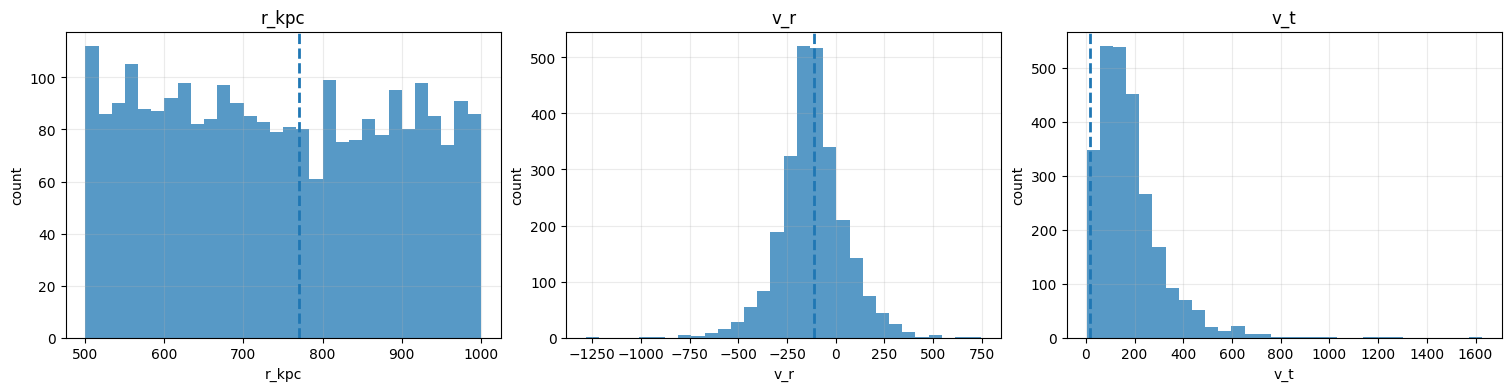

In [4]:
plot_feature_histograms(X, x_obs, feature_names=feature_names)
plt.show()


## 3) Train NPE directly in the notebook

This is the part meant to stay close to the practical-guide examples: convert arrays to tensors, create the density estimator, append simulations, train, and build the posterior.


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
random_state = SBI_CONFIG["random_state"]
if random_state is not None:
    np.random.seed(random_state)
    torch.manual_seed(int(random_state))

theta_tensor = torch.as_tensor(theta[:, None], dtype=torch.float32, device=device)
x_tensor = torch.as_tensor(X, dtype=torch.float32, device=device)
x_obs_tensor = torch.as_tensor(x_obs, dtype=torch.float32, device=device)

density_estimator = posterior_nn(
    model=SBI_CONFIG["density_model"],
    z_score_theta="independent",
    z_score_x="independent",
    hidden_features=SBI_CONFIG["hidden_features"],
    num_transforms=SBI_CONFIG["num_transforms"],
)

inference = NPE(prior=None, density_estimator=density_estimator, device=device)
inference.append_simulations(theta_tensor, x_tensor)
trained_density_estimator = inference.train(
    training_batch_size=SBI_CONFIG["training_batch_size"],
    learning_rate=SBI_CONFIG["learning_rate"],
    validation_fraction=SBI_CONFIG["validation_fraction"],
    stop_after_epochs=SBI_CONFIG["stop_after_epochs"],
    max_num_epochs=SBI_CONFIG["max_num_epochs"],
    clip_max_norm=SBI_CONFIG["clip_max_norm"],
    show_train_summary=False,
)
posterior = inference.build_posterior(trained_density_estimator, sample_with="direct")

print("Training finished on device:", device)
print("Density model:", SBI_CONFIG["density_model"])


/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 78 epochs.Training finished on device: cpu
Density model: maf


## 4) Sample from the posterior and summarize the result


,mean,median,q16,q84
NPE posterior,12.300507,12.29947,12.021952,12.578684


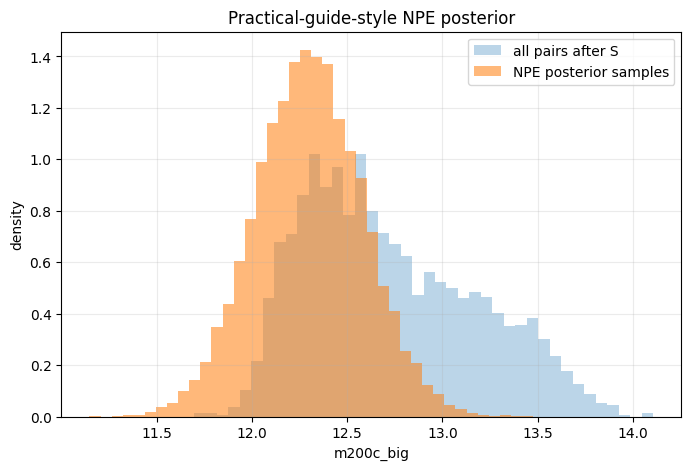

In [6]:
posterior_samples = posterior.sample(
    (SBI_CONFIG["num_posterior_samples"],),
    x=x_obs_tensor,
    show_progress_bars=False,
).detach().cpu().numpy().reshape(-1)

posterior_summary = summarize_1d(posterior_samples)
display(pd.DataFrame([posterior_summary], index=["NPE posterior"]))

plot_1d_posterior_comparison(
    theta,
    posterior_samples,
    target_name=target_name,
    title="Practical-guide-style NPE posterior",
)
plt.show()
